In [2]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB 330.3 kB/s eta 0:00:30
   ---------------------------------------- 0.0/9.8 MB 393.8 kB/s eta 0:00:25
   ---------------------------------------- 0.1/9.8 MB 819.2 kB/s eta 0:00:12
    --------------------------------------- 0.2/9.8 MB 1.1 MB/s eta 0:00:09
   - -------------------------------------- 0.3/9.8 MB 1.4 MB/s eta 0:00:07
   - -------------------------------------- 0.5/9.8 MB 1.8 MB/s eta 0:00:06
   --- ------------------------------------ 0.7/9.8 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.1/9.8 MB 2.9 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/9.8 MB 3.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.0/9.8 MB 4.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.8 MB 5.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.2/9.8 MB 6.0 MB/s eta 0:00:02
   ----------

In [3]:
# Time Series Decomposition Demonstration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [4]:
# Step 1: Create a synthetic dataset
np.random.seed(42)

# Generate monthly date range over 4 years
date_range = pd.date_range(start='2018-01-01', periods=48, freq='M')

C:\Users\user\AppData\Local\Temp\ipykernel_14968\104691211.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start='2018-01-01', periods=48, freq='M')


In [5]:

# Create components: trend, seasonality, and noise
trend = np.linspace(50, 100, 48)  # Linear trend from 50 to 100
seasonality = 10 * np.sin(2 * np.pi * date_range.month / 12)  # Seasonal pattern
noise = np.random.normal(0, 3, 48)  # Random noise

In [6]:
# Combine components to form the time series
data = trend + seasonality + noise

In [7]:
# Create DataFrame
df = pd.DataFrame({'Date': date_range, 'Sales': data})
df.set_index('Date', inplace=True)

In [8]:
df

,Sales
Date,
2018-01-31,56.490142
2018-02-28,59.309291
2018-03-31,64.070725
2018-04-30,66.420833
2018-05-31,58.552859
2018-06-30,54.616738
2018-07-31,56.120617
2018-08-31,51.088859
2018-09-30,47.102215


In [9]:
# Step 2: Decompose the time series
decomposition = seasonal_decompose(df['Sales'], model='additive', period=12)


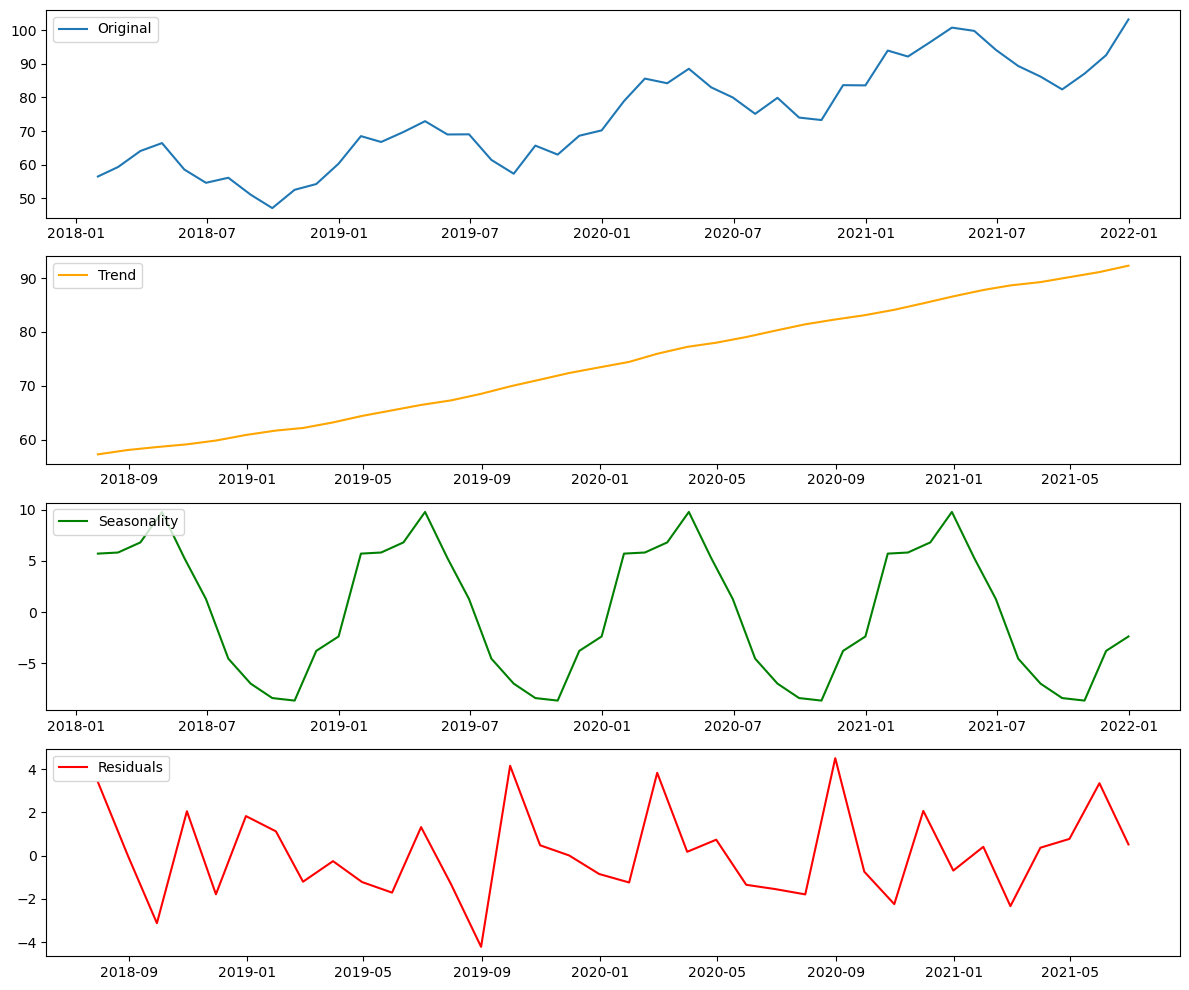

In [10]:
# Step 3: Plot the decomposition results
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(decomposition.observed, label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()